<a href="https://colab.research.google.com/github/Josmanr3/TFG_Psoriasis/blob/main/Psoriasis_clasificacion_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Clasificación de Imágenes de Psoriasis
"""

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import xml.etree.ElementTree as ET
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import random

# Configuración global
IMG_SIZE = (224, 224)
BATCH_SIZE = 64  #con 16 o 32 más fluctuaciones en las curvas
LEARNING_RATE = 1e-4
EPOCHS = 50

# Descargar el dataset desde Google Drive
def download_dataset():
    from google.colab import drive
    drive.mount('/content/drive')

    ruta_zip = '/content/drive/MyDrive/Psoriasis_dataset.zip'
    dataset_path = '/content/psoriasis_dataset/'

    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(dataset_path)

    os.listdir(dataset_path)
    return dataset_path

#  Mostrar imágenes aleatorias del dataset
def mostrar_imagenes_aleatorias(dataset_path, num_images=9):
    # Identificar directorios
    train_dir = os.path.join(dataset_path, 'train')

    # Obtener todas las clases (carpetas)
    clases = os.listdir(train_dir)

    plt.figure(figsize=(15, 15))

    for i in range(num_images):
        # Seleccionar una clase aleatoria
        clase = random.choice(clases)
        clase_path = os.path.join(train_dir, clase)

        # Obtener una imagen aleatoria de esa clase
        imagenes = os.listdir(clase_path)
        imagen = random.choice(imagenes)
        img_path = os.path.join(clase_path, imagen)

        # Cargar y mostrar la imagen
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(f"Clase: {clase}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Mostrando {num_images} imágenes aleatorias del dataset")

def cargar_generadores(dataset_path):
    train_dir = os.path.join(dataset_path, 'train')
    val_dir = os.path.join(dataset_path, 'val')
    test_dir = os.path.join(dataset_path, 'test')

    # Augmentación solo en entrenamiento
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        #vertical_flip=True,
        brightness_range=[0.8, 1.2],
        #shear_range=0.1,
        fill_mode='nearest'
    )

    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )

    val_gen = val_test_datagen.flow_from_directory(
        val_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, val_gen, test_gen



In [2]:
def crear_modelo(num_classes):
    # Modelo base
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Fine-tuning: descongelar algunas capas superiores para un mejor ajuste
    # Congelar las primeras capas y descongelar las últimas
    for layer in base_model.layers[:-50]:  # Mantener congeladas las primeras capas
        layer.trainable = False

    for layer in base_model.layers[-50:]:  # Descongelar las últimas X capas
        layer.trainable = True

    # Construir el modelo completo
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Pasamos los inputs directamente al modelo base
    # (el preprocess_input ya está aplicado en el generador)
    x = base_model(inputs, training=False)

    # Cabeza de clasificación
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    # Compilación
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    # Muestra las capas del modelo
    model.summary()

    return model

In [3]:
# Evaluar el modelo usando los generadores directamente
def evaluar_modelo(model, test_gen, class_names):
    # Evaluación general
    print("\nEvaluación en el conjunto de prueba:")
    results = model.evaluate(test_gen, verbose=1)

    # Obtener predicciones
    test_gen.reset()  # Reiniciar el generador
    y_pred = model.predict(test_gen)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = test_gen.classes

    # Función para obtener un lote de imágenes
    def get_batch_of_images(generator, n=9):
        generator.reset()
        batch_x, batch_y = next(generator)
        true_classes = np.argmax(batch_y, axis=1)
        return batch_x[:n], true_classes[:n]

    # Obtener algunas imágenes para visualizar
    sample_images, sample_true_classes = get_batch_of_images(test_gen)
    sample_pred_classes = np.argmax(model.predict(sample_images), axis=1)

    # Mostrar algunas predicciones
    plt.figure(figsize=(15, 10))
    for i in range(len(sample_images)):
        plt.subplot(3, 3, i + 1)
        # Deshacer el preprocesamiento para visualización
        img = sample_images[i]
        # Normalizar para visualización si es necesario
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)

        pred_class = class_names[sample_pred_classes[i]]
        true_class = class_names[sample_true_classes[i]]
        title = f"Pred: {pred_class}\nTrue: {true_class}"
        plt.title(title, color=("green" if pred_class == true_class else "red"))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Importar las métricas
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns

    # Reporte de clasificación
    print("\nReporte de clasificación:")
    report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
    print(report)

    # Matriz de confusión
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión')
    plt.show()

    return results

# Graficar el historial de entrenamiento
def graficar_historial(history):
    plt.figure(figsize=(12, 5))

    # Gráfico de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    # Gráfico de precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    plt.tight_layout()
    plt.show()

Mounted at /content/drive


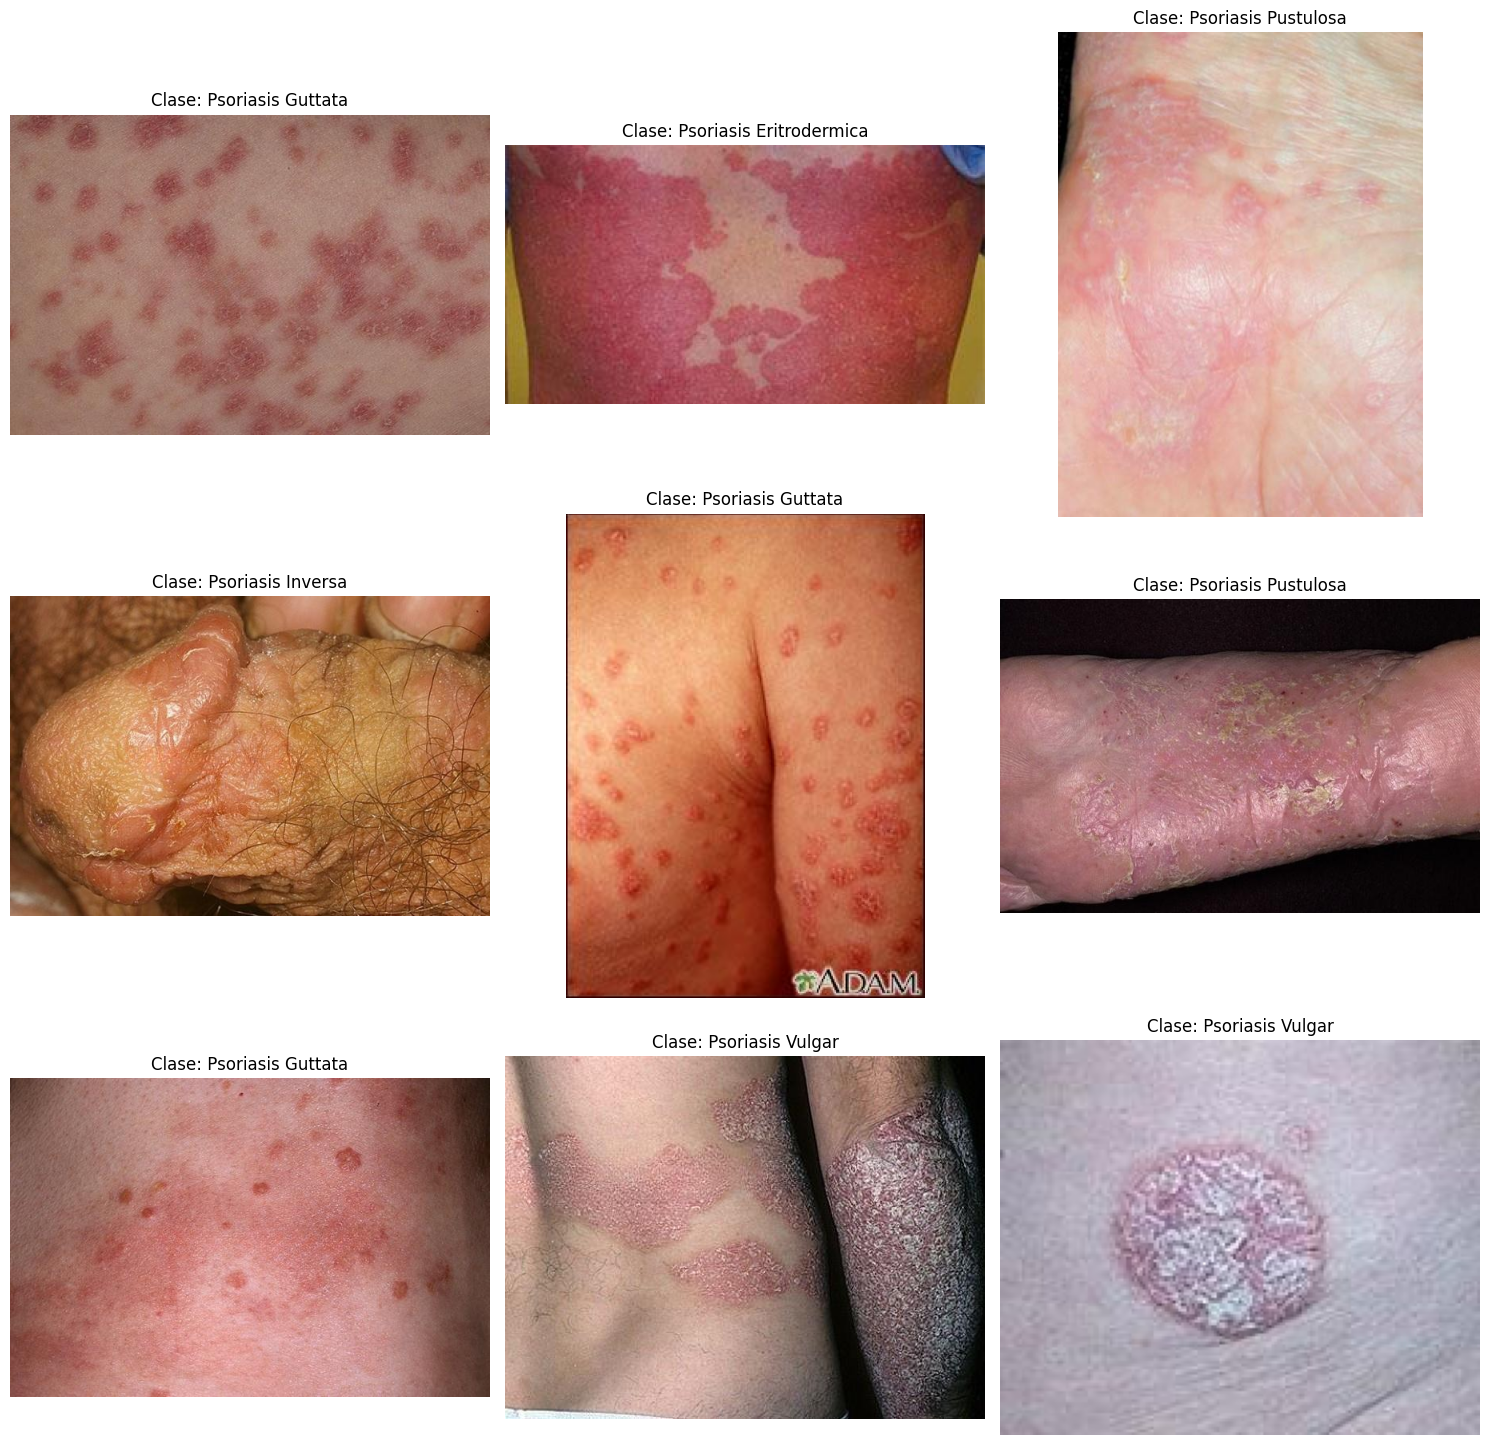

Mostrando 9 imágenes aleatorias del dataset
Found 312 images belonging to 5 classes.
Found 90 images belonging to 5 classes.
Found 45 images belonging to 5 classes.

=== INFORMACIÓN DEL DATASET ===
Imágenes de entrenamiento: 312
Imágenes de validación: 90
Imágenes de prueba: 45
Total de imágenes: 447

Clases encontradas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

=== DISTRIBUCIÓN DE CLASES (ENTRENAMIENTO) ===
Clase Psoriasis Eritrodermica: 68 imágenes
Clase Psoriasis Guttata: 33 imágenes
Clase Psoriasis Inversa: 47 imágenes
Clase Psoriasis Pustulosa: 69 imágenes
Clase Psoriasis Vulgar: 95 imágenes

=== PESOS PARA BALANCEO DE CLASES ===
Clase Psoriasis Eritrodermica: 0.9176
Clase Psoriasis Guttata: 1.8909
Clase Psoriasis Inversa: 1.3277
Clase Psoriasis Pustulosa: 0.9043
Clase Psoriasis Vulgar: 0.6568

Creando modelo...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,757 (92.02 MB)

 Trainable params: 17,480,965 (66.68 MB)

 Non-trainable params: 6,641,792 (25.34 MB)


Entrenando modelo...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 107s 19s/step - accuracy: 0.2235 - loss: 2.8626 - precision: 0.2511 - recall: 0.1892 - val_accuracy: 0.1556 - val_loss: 2.4463 - val_precision: 0.1000 - val_recall: 0.0333 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 136s 18s/step - accuracy: 0.2991 - loss: 2.4679 - precision: 0.3154 - recall: 0.2428 - val_accuracy: 0.2556 - val_loss: 2.0720 - val_precision: 0.2593 - val_recall: 0.0778 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 17s/step - accuracy: 0.2966 - loss: 2.1433 - precision: 0.3316 - recall: 0.2693 - val_accuracy: 0.3444 - val_loss: 1.7942 - val_precision: 0.4118 - val_recall: 0.1556 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 86s 17s/step - accuracy: 0.3424 - loss: 1.9860 - precision: 0.3719 - recall: 0.2805 - val_accuracy: 0.4222 - val_loss: 1.5933 - val_precision: 0.5750 - val_recall: 0.2556 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 141s 17s/step - accura

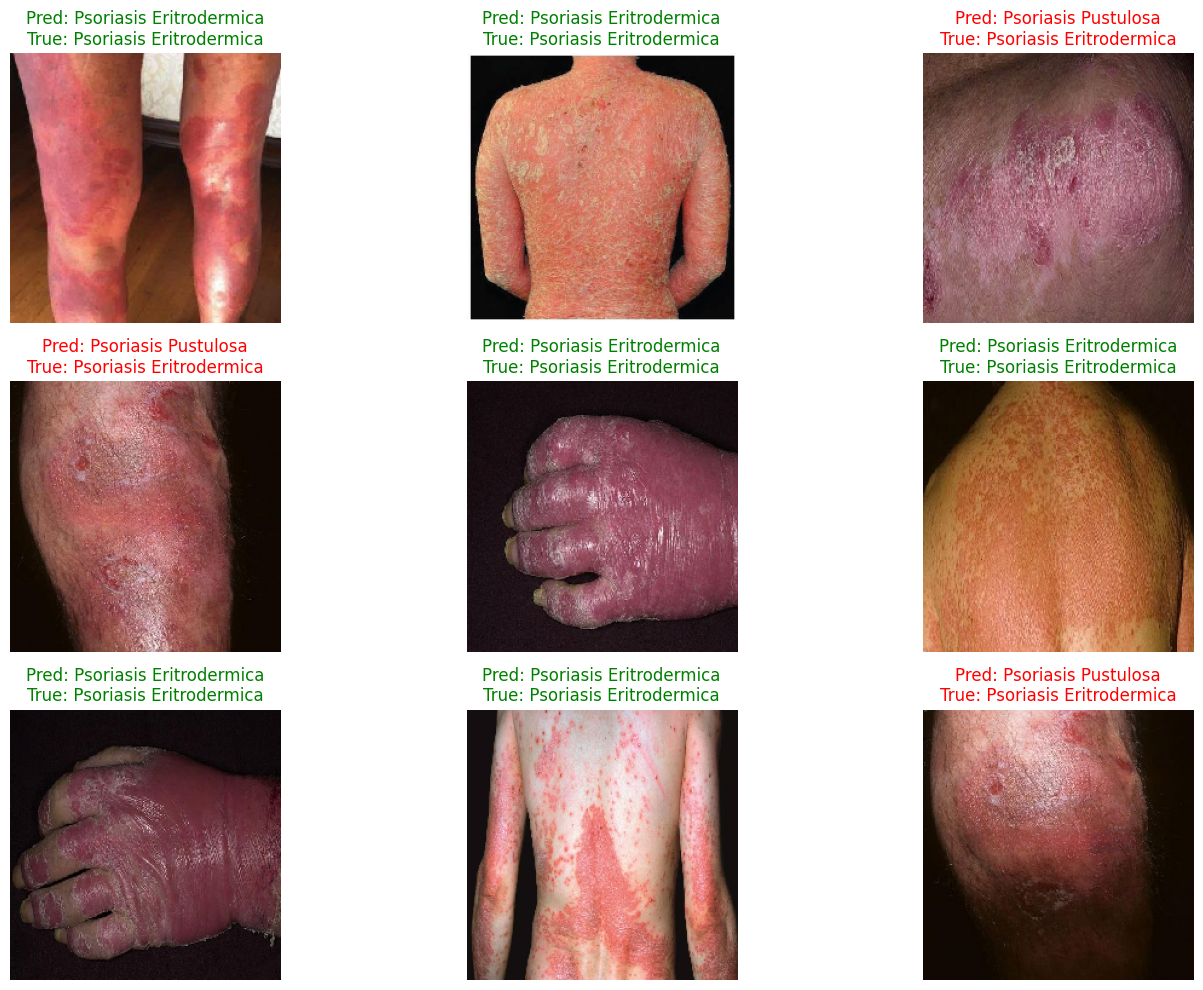


Reporte de clasificación:
                         precision    recall  f1-score   support

Psoriasis Eritrodermica       0.86      0.60      0.71        10
      Psoriasis Guttata       0.80      1.00      0.89         4
      Psoriasis Inversa       0.67      0.86      0.75         7
    Psoriasis Pustulosa       0.55      0.60      0.57        10
       Psoriasis Vulgar       0.69      0.64      0.67        14

               accuracy                           0.69        45
              macro avg       0.71      0.74      0.72        45
           weighted avg       0.70      0.69      0.69        45



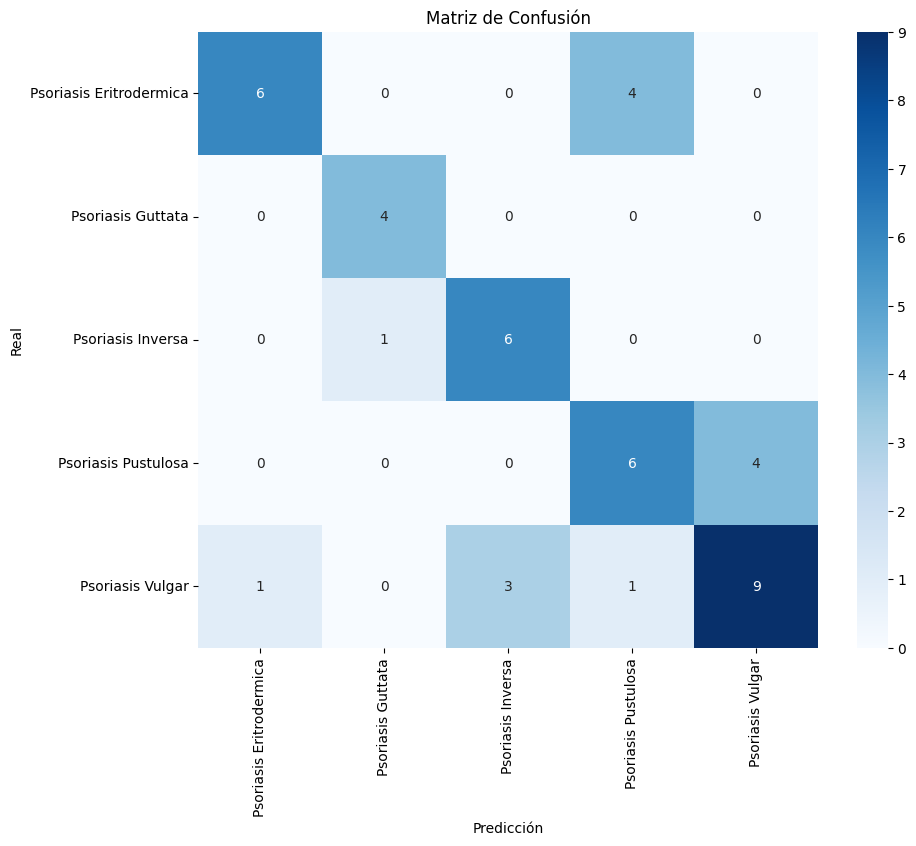

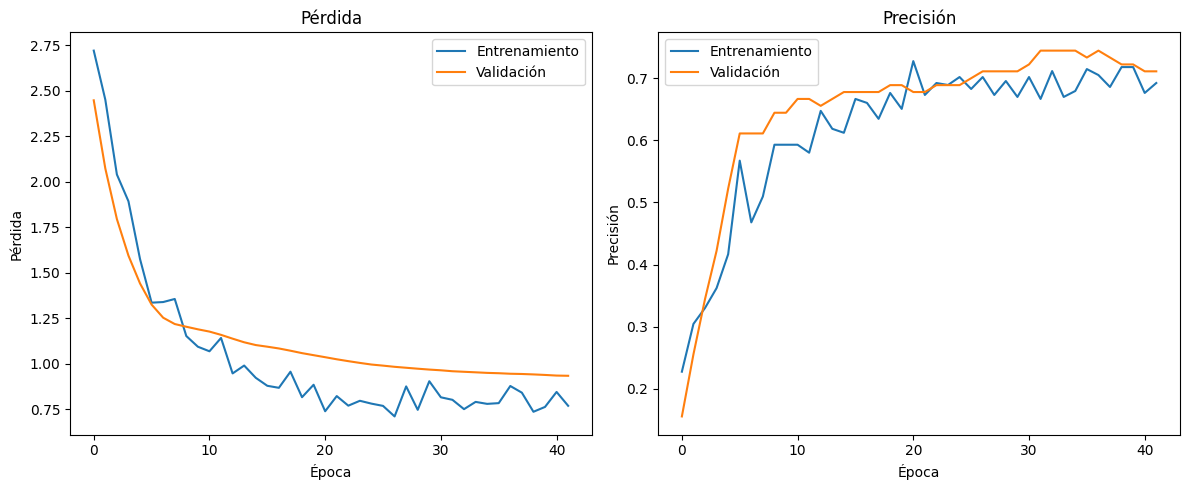


Modelo guardado como 'ResNet50_final.h5'


In [4]:
# Función principal corregida
def main():
    # 1. Descargar y descomprimir el dataset
    dataset_path = download_dataset()
    dataset_path = os.path.join(dataset_path, 'dataset_split')

    # 2. Mostrar algunas imágenes aleatorias del dataset
    mostrar_imagenes_aleatorias(dataset_path)

    # 3. Cargar generadores
    train_gen, val_gen, test_gen = cargar_generadores(dataset_path)

    # Mostrar información sobre el tamaño de los conjuntos de datos
    print("\n=== INFORMACIÓN DEL DATASET ===")
    print(f"Imágenes de entrenamiento: {train_gen.samples}")
    print(f"Imágenes de validación: {val_gen.samples}")
    print(f"Imágenes de prueba: {test_gen.samples}")
    print(f"Total de imágenes: {train_gen.samples + val_gen.samples + test_gen.samples}")

    # 4. Obtener nombres de clases
    class_names = list(train_gen.class_indices.keys())
    num_classes = len(class_names)

    print(f"\nClases encontradas ({num_classes}): {class_names}")

    # Mostrar la distribución de clases en el conjunto de entrenamiento
    unique_classes, counts = np.unique(train_gen.classes, return_counts=True)
    print("\n=== DISTRIBUCIÓN DE CLASES (ENTRENAMIENTO) ===")
    for i, clase in enumerate(unique_classes):
        print(f"Clase {class_names[clase]}: {counts[i]} imágenes")

    # 5. Calcular pesos de clase
    y_train_labels = train_gen.classes
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_labels),
        y=y_train_labels
    )
    class_weight_dict = dict(enumerate(class_weights))

    # Mostrar los pesos calculados para el balanceo de clases
    print("\n=== PESOS PARA BALANCEO DE CLASES ===")
    for i, peso in class_weight_dict.items():
        print(f"Clase {class_names[i]}: {peso:.4f}")

    # 6. Crear modelo
    print("\nCreando modelo...")
    model = crear_modelo(num_classes)

    # 7. Entrenar modelo
    print("\nEntrenando modelo...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
            ModelCheckpoint('ResNet50_best.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
            ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-7)
        ],
        class_weight=class_weight_dict
    )

    # 8. Evaluar el modelo
    print("\nEvaluando modelo...")
    results = evaluar_modelo(model, test_gen, class_names)

    # 9. Visualizar el historial de entrenamiento
    graficar_historial(history)

    # 10. Guardar el modelo
    model.save('ResNet50.h5')
    print("\nModelo guardado como 'ResNet50_final.h5'")

    return model, history, results

if __name__ == "__main__":
    main()